In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [8]:
df = pd.read_csv("Crop_recommendation.csv")
df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [9]:
print("Shape:", df.shape)
df.info()

Shape: (2200, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
df.isnull().sum()
df.duplicated().sum()

0

In [12]:
df.drop_duplicates(inplace=True)

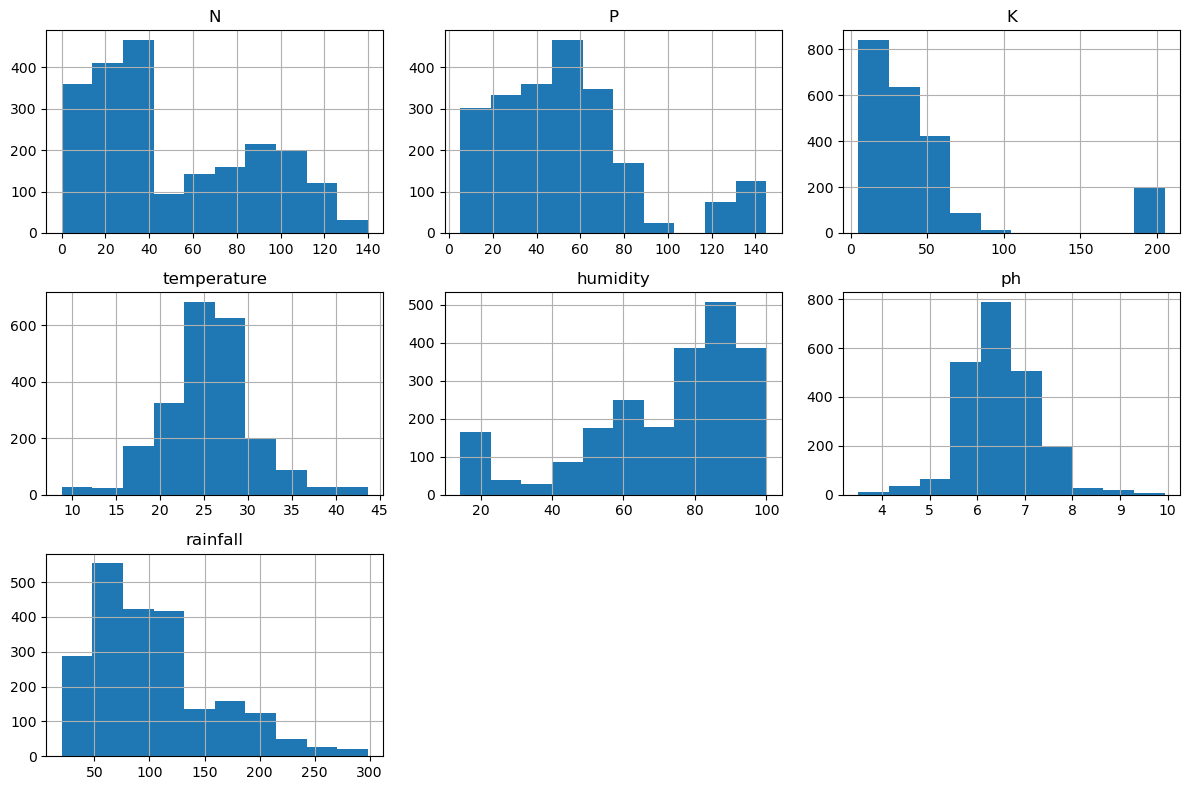

In [13]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

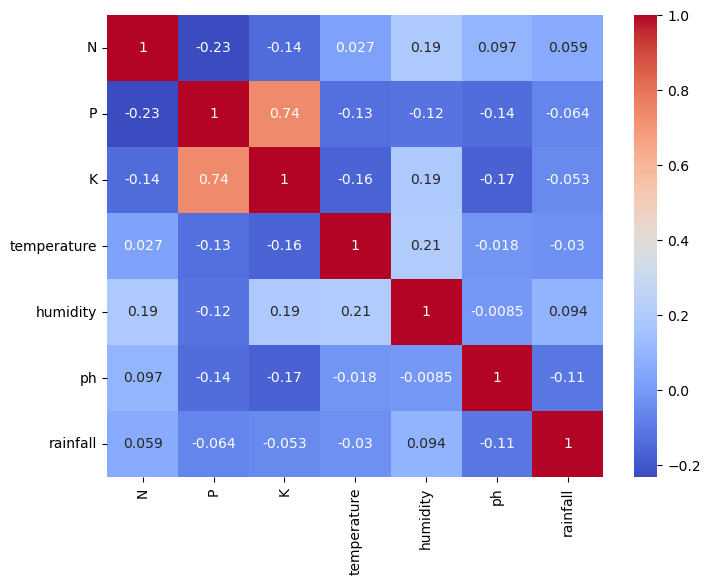

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(),
            annot=True, cmap="coolwarm")
plt.show()

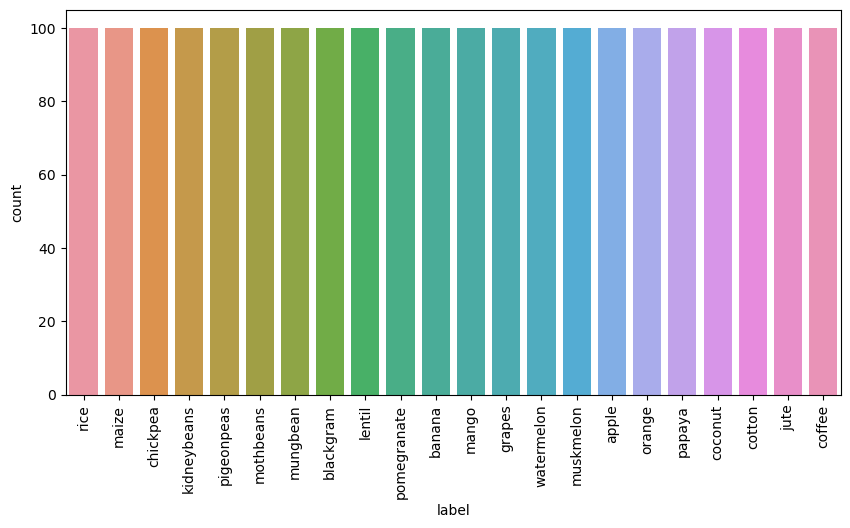

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(x="label", data=df)
plt.xticks(rotation=90)
plt.show()

In [16]:
X = df.drop("label", axis=1)
y = df["label"]

In [17]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [20]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [21]:
y_pred = rf_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(
    y_test, y_pred, target_names=label_encoder.classes_
))

Accuracy: 0.9954545454545455
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        2

In [35]:
import matplotlib.pyplot as plt

def predict_top_5_with_usercrop(model, scaler, label_encoder, input_data, user_crop):

    df_input = pd.DataFrame([input_data])
    scaled = scaler.transform(df_input)

    probs = model.predict_proba(scaled)[0]

    # Top 5 crops
    top5_idx = np.argsort(probs)[-5:][::-1]

    crops = []
    confs = []

    for idx in top5_idx:
        crop = label_encoder.inverse_transform([idx])[0]
        conf = round(probs[idx] * 100, 2)

        crops.append(crop)
        confs.append(conf)

    
    if user_crop in label_encoder.classes_:
        crop_idx = list(label_encoder.classes_).index(user_crop)
        user_prob = round(probs[crop_idx] * 100, 2)

        
        if user_crop not in crops:
            crops.append(user_crop)
            confs.append(user_prob)
    else:
        user_prob = None

  
    colors = []
    for c in crops:
        if c == user_crop:
            colors.append("red")       # highlighted crop
        else:
            colors.append("skyblue")   # default crops
   

    # --------- BAR CHART ----------
    plt.figure(figsize=(7,4))
    plt.bar(crops, confs, color=colors)
    plt.xlabel("Crops")
    plt.ylabel("Suitability Confidence (%)")
    plt.title("Top 5 Recommended Crops + Your Selected Crop")
    plt.ylim(0, 100)
    plt.xticks(rotation=15)
    plt.show()
    

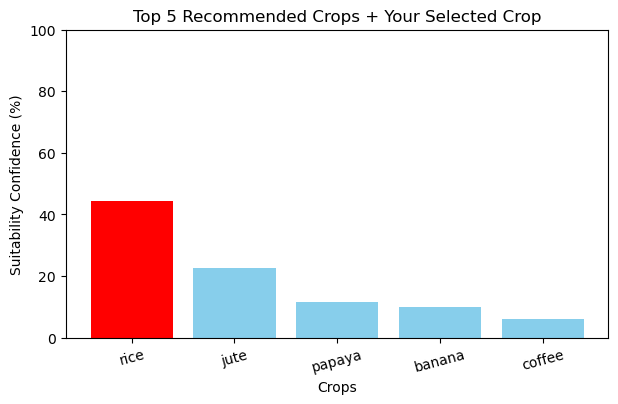

In [36]:
sample = {
    "N": 90, "P": 42, "K": 43,
    "temperature": 28.8,
    "humidity": 82,
    "ph": 6.5,
    "rainfall": 202
}

predict_top_5_with_usercrop(
    rf_model,
    scaler,
    label_encoder,
    sample,
    user_crop="rice"
)


In [37]:
import os
os.makedirs("models", exist_ok=True)

In [38]:
import joblib

joblib.dump(rf_model, "models/rf_model.pkl")
joblib.dump(scaler, "models/scaler.pkl")
joblib.dump(label_encoder, "models/label_encoder.pkl")

print("Files saved successfully!")

Files saved successfully!
